# TP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# - - - Parametres physiques - - -
L = 1.0
# Longueur de la barre ( m )
alpha = 1.11e-4
# Diffusivite thermique du cuivre ( m ^2 / s )
T_gauche = 100.0
# Temperature a x = 0 ( degC )
T_droite = 0.0
# Temperature a x = L ( degC )
T_init = 0.0
# Temperature initiale uniforme ( degC )
# - - - Parametres numeriques - - -
N = 20 # Nombre d ’ intervalles spatiaux
dx = L / N # Pas spatial ( m )
r = 0.4 # Nombre de Fourier discret ( choisir r <= 0.5)
dt = r*dx**2/alpha # Pas de temps : a calculer depuis r , dx et alpha
t_fin = 3000 # Duree de simulation ( s )
nt = int ( t_fin / dt )
print (f" dx = {dx:.4f}m")
print (f" dt = {dt:.4f}s")
print (f" r = {r:.4f}( doit etre <= 0.5) " )
print (f" Nombre de pas de temps : {nt}" )


 dx = 0.0500m
 dt = 9.0090s
 r = 0.4000( doit etre <= 0.5) 
 Nombre de pas de temps : 332


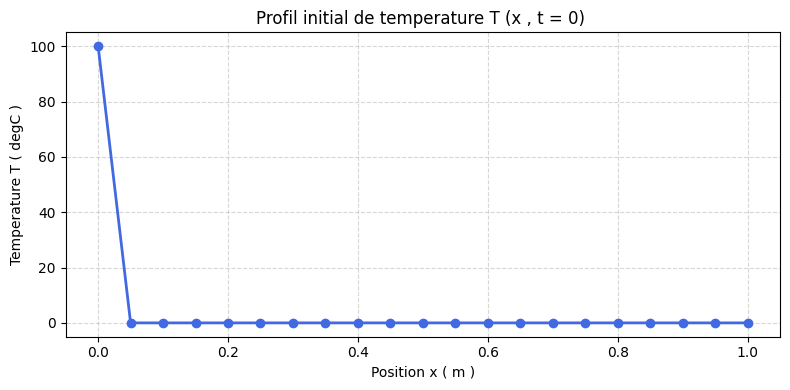

In [2]:
# - - - Creation de la grille spatiale - - -
x = np.linspace(0, L, N+1) # N + 1 points de x = 0 a x = L
# - - - Condition initiale - - -
T = np.ones (N + 1) * T_init
# - - - Application des conditions aux limites - - -
T[0] = T_gauche
T[-1] = T_droite

# - - - Visualisation du profil initial - - -
fig, ax = plt.subplots(figsize= (8, 4) )
ax.plot (x , T , "o-"  , color="royalblue", linewidth = 2 ,markersize = 6)
ax.set_xlabel (  "Position x ( m )" )
ax.set_ylabel ( "Temperature T ( degC )" )
ax.set_title ( "Profil initial de temperature T (x , t = 0) " )
ax.grid (True, linestyle = "--"  , alpha = 0.5)
plt.tight_layout()
plt.show()

In [3]:
save_frac = 10
save_step = max(1 , nt//save_frac)
T_save = [T.copy()]
t_save = [0.0]
T_new = T.copy()
for n in range (1 , nt + 1) :
# Mise a jour des noeuds interieurs ( i = 1 a N - 1)
    for i in range (1 , N ) :
        T_new[i] = T[i] + r * (T[i+1] - 2*T[i] + T[i-1])
    T = T_new.copy() # pourquoi " copy " ?
    # Sauvegarde periodique
    if n % save_step == 0:
        T_save.append(T.copy()) # pourquoi " copy " ?
        t_save.append(n * dt)
T_save = np.array ( T_save )
print ( f" Nombre de profils sauvegardes : {len(T_save)} " )


 Nombre de profils sauvegardes : 11 


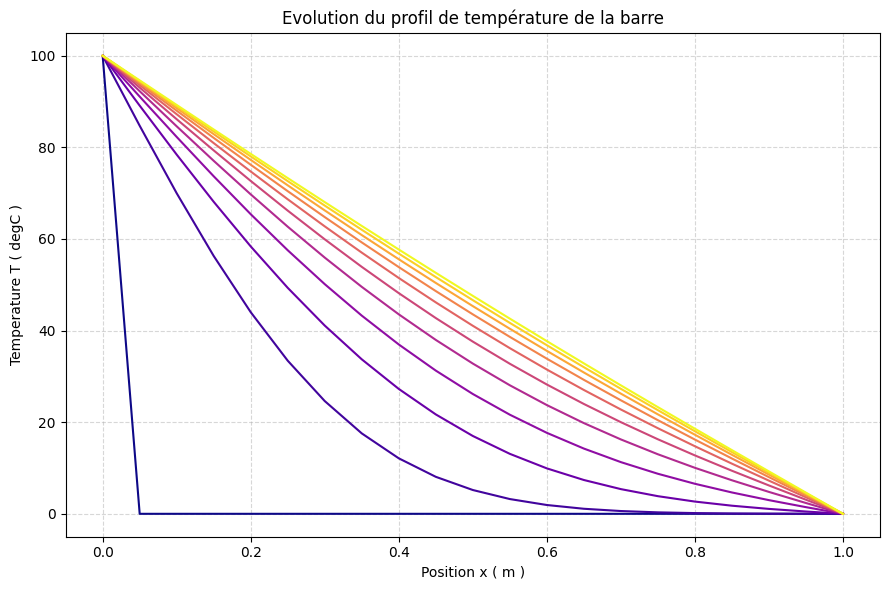

In [4]:
fig , ax = plt.subplots(figsize = (9 , 6) )
colors = cm.plasma(np.linspace(0 , 1 , len(T_save)))

for k, (T_k, t_k) in enumerate(zip(T_save, t_save)):
    ax.plot (x , T_k , color=colors[k], label=f"t = {t_k:.0f} s")

ax.set_xlabel (  "Position x ( m )" )
ax.set_ylabel ( "Temperature T ( degC )" )
ax.set_title ( "Evolution du profil de température de la barre" )
ax.grid (True, linestyle = "--"  , alpha = 0.5)
plt.tight_layout()
plt.show()

 Nombre de profils sauvegardes : 11 


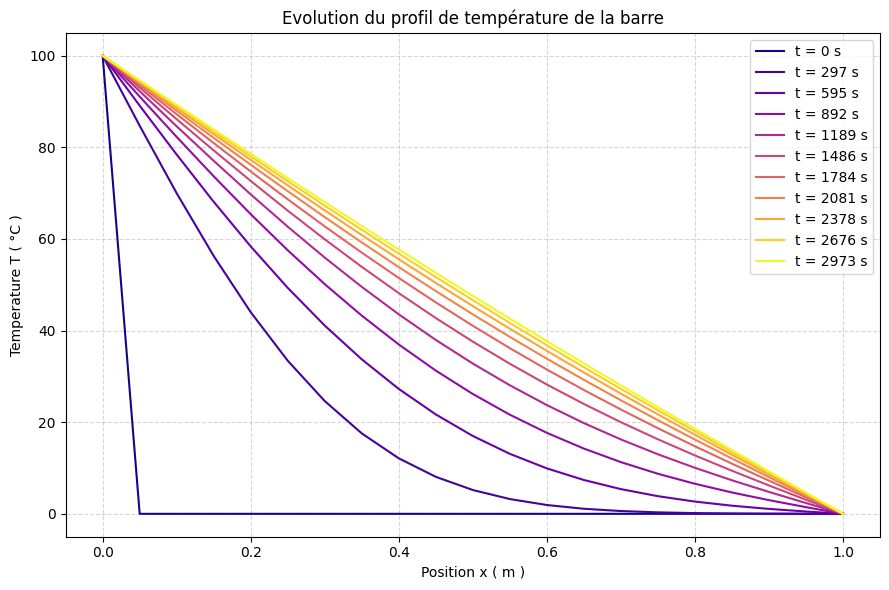

In [5]:
from sim import *

x, t, T = simulation_chaleur(L, alpha, N, r, t_fin, T_gauche, T_droite, T_init)

Tracer_T_x(x, t, T)

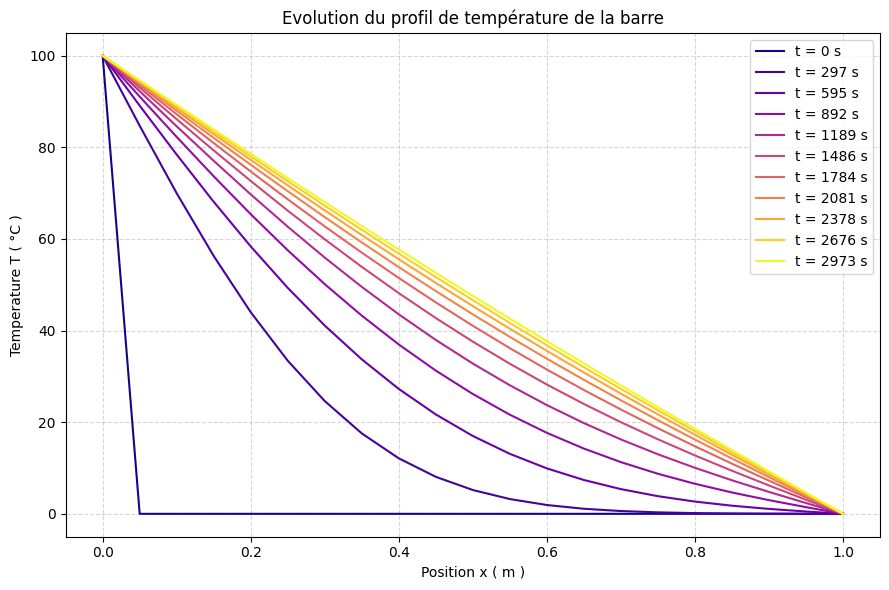

In [6]:
x, t, T = simulation_chaleur_vect(L=L, alpha=alpha, N=N, r=r, t_fin=t_fin, T_gauche=T_gauche, T_droite=T_droite, T_init=0)

Tracer_T_x(x, t, T)

In [7]:
import time

debut = time.time()
x, t, T = simulation_chaleur(L, alpha, N=400, r=0.4,t_fin=3000,T_gauche=100, T_droite=0, T_init=0)
fin = time.time()
print(f"Temps avec boucle for : {fin- debut:.3f} s")

debut = time.time()
x, t, T = simulation_chaleur_vect(L, alpha, N=400, r=0.4,t_fin=3000,T_gauche=100, T_droite=0, T_init=0)
fin = time.time()
print(f"Temps version vectorisée : {fin- debut:.3f} s")

 Nombre de profils sauvegardes : 11 
Temps avec boucle for : 38.541 s
Temps version vectorisée : 0.759 s


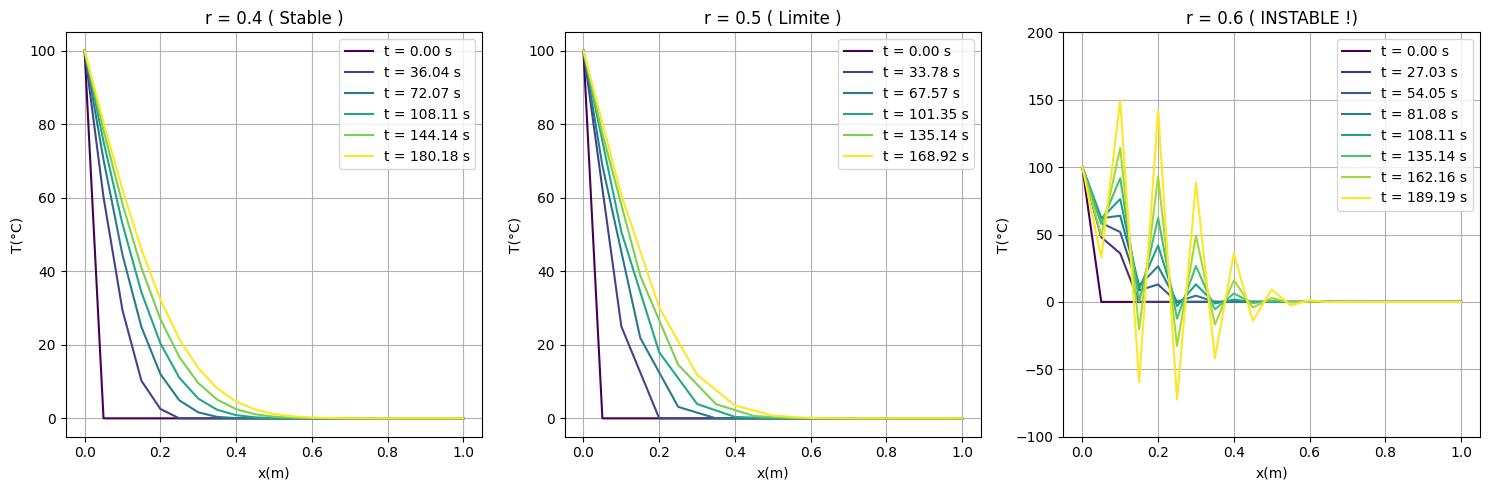

In [8]:
fig, axes = plt.subplots (1 , 3 , figsize = (15 , 5) )
r_values = [0.4 , 0.5 , 0.6]
titres = [ "r = 0.4 ( Stable )" , "r = 0.5 ( Limite )", "r = 0.6 ( INSTABLE !)"]
for ax , r_val , titre in zip ( axes , r_values , titres ) :
    x, t, T_sv_r = simulation_chaleur_vect(L=1, alpha=1.11e-4, N=20, r=r_val, t_fin=200,T_gauche=100, T_droite=0, T_init=0, save_step_frac=5 )
    colors = cm . viridis ( np . linspace (0 , 1 , len ( T_sv_r ) ) )
    for k, (T_k, t_k) in enumerate(zip(T_sv_r, t)):
        ax.plot (x , T_k , color=colors[k], label=f"t = {t_k:.2f} s")

    ax.set_title(titre)
    ax.set_xlabel("x(m)")
    ax.set_ylabel("T(°C)")
    ax.legend()
    if r_val > 0.5:
        ax.set_ylim(-100,200)
    ax.grid()
plt.tight_layout ()
plt.show ()


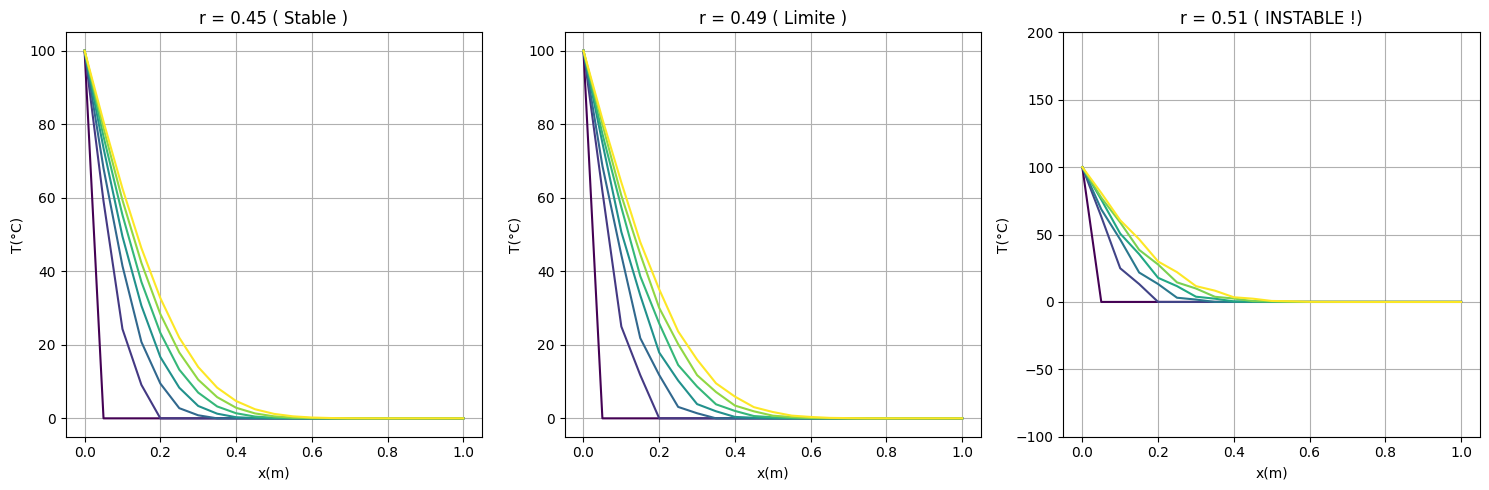

In [9]:
fig, axes = plt.subplots (1 , 3 , figsize = (15 , 5) )
r_values = [0.45 , 0.49 , 0.51]
titres = [ "r = 0.45 ( Stable )" , "r = 0.49 ( Limite )", "r = 0.51 ( INSTABLE !)"]
for ax , r_val , titre in zip ( axes , r_values , titres ) :
    x, t, T_sv_r = simulation_chaleur_vect(L=1, alpha=1.11e-4, N=20, r=r_val, t_fin=200,T_gauche=100, T_droite=0, T_init=0, save_step_frac=5 )
    colors = cm . viridis ( np . linspace (0 , 1 , len ( T_sv_r ) ) )
    for k, (T_k, t_k) in enumerate(zip(T_sv_r, t)):
        ax.plot (x , T_k , color=colors[k])

    ax.set_title(titre)
    ax.set_xlabel("x(m)")
    ax.set_ylabel("T(°C)")
    if r_val > 0.5:
        ax.set_ylim(-100,200)
    ax.grid()
plt.tight_layout ()
plt.show ()

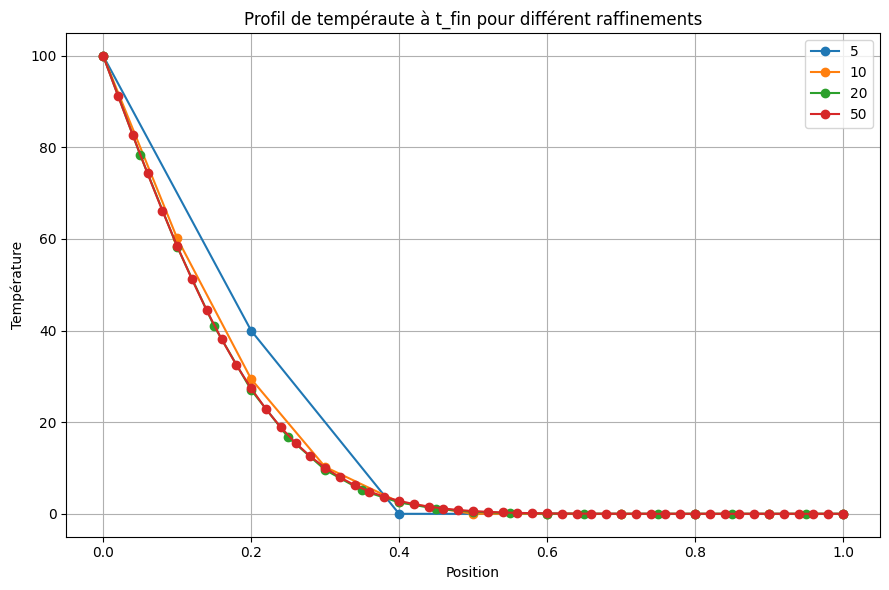

In [10]:
N_values = [5, 10, 20, 50]

fig, ax = plt.subplots(figsize=(9,6))

for N_val in N_values:
    x_n, t_sv, T_sv = simulation_chaleur_vect(L=1, alpha=1.11e-5, N=N_val, r=0.4, t_fin=1500,T_gauche=100, T_droite=0, T_init=0, save_step_frac=1)
    ax.plot(x_n , T_sv[-1],marker='o', label=f"{N_val}")

ax.set_xlabel("Position")
ax.set_ylabel("Température")
ax.set_title("Profil de tempéraute à t_fin pour différent raffinements")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

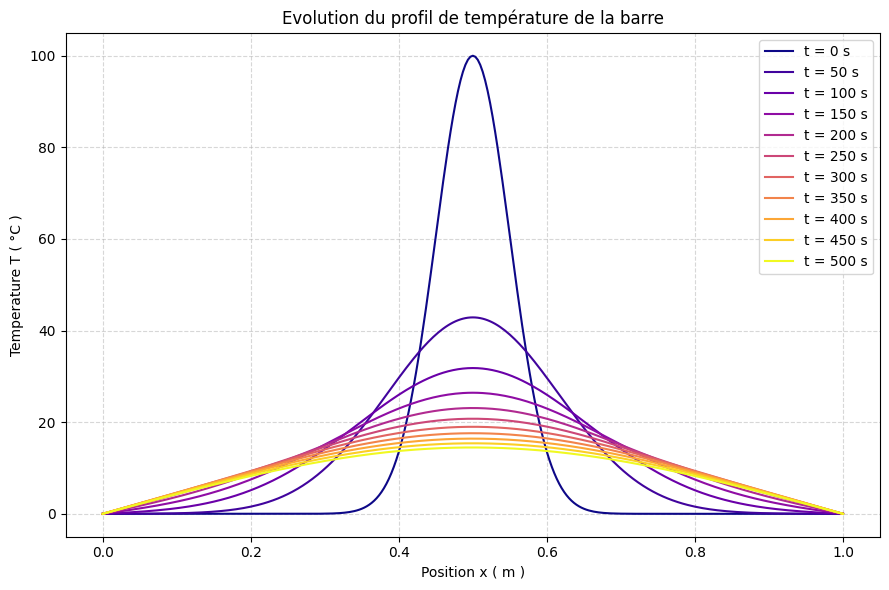

In [ ]:
def f_init_gauss(x):
    sigma= 0.05
    T_max= 100
    L = x[-1]
    return T_max* np.exp(-((x - L/2)**2)/(2*sigma**2))

x, t_save, T_save = simulation_chaleur_vect_f(L, alpha, N=300, r=0.4, t_fin=500, T_gauche=0, T_droite=0, f_init=f_init_gauss)
Tracer_T_x(x, t_save, T_save)


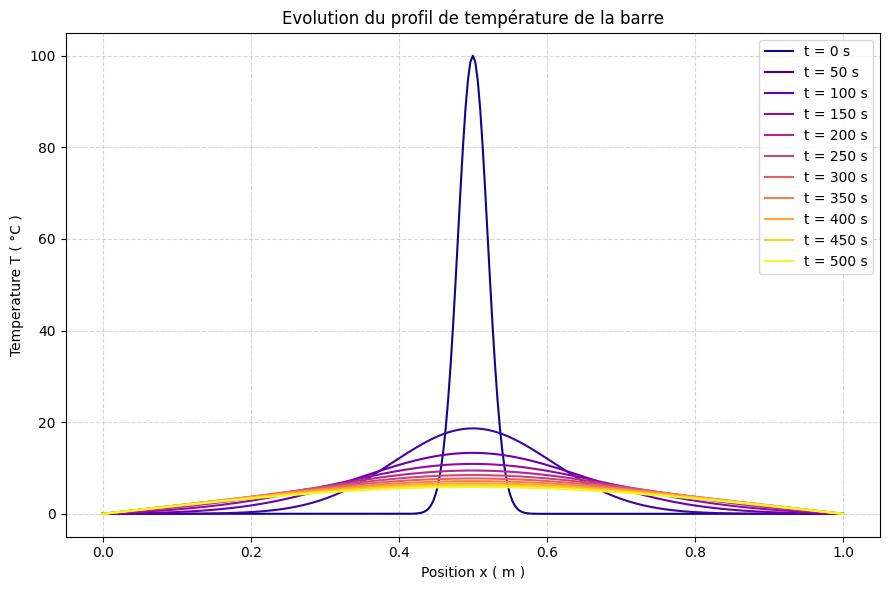

In [28]:
def f_init_gauss(x):
    sigma= 0.02
    T_max= 100
    L = x[-1]
    return T_max* np.exp(-((x - L/2)**2)/(2*sigma**2))

Tracer_T_x(*simulation_chaleur_vect_f(L, alpha, N=300, r=0.4, t_fin=500, T_gauche=0, T_droite=0, f_init=f_init_gauss))

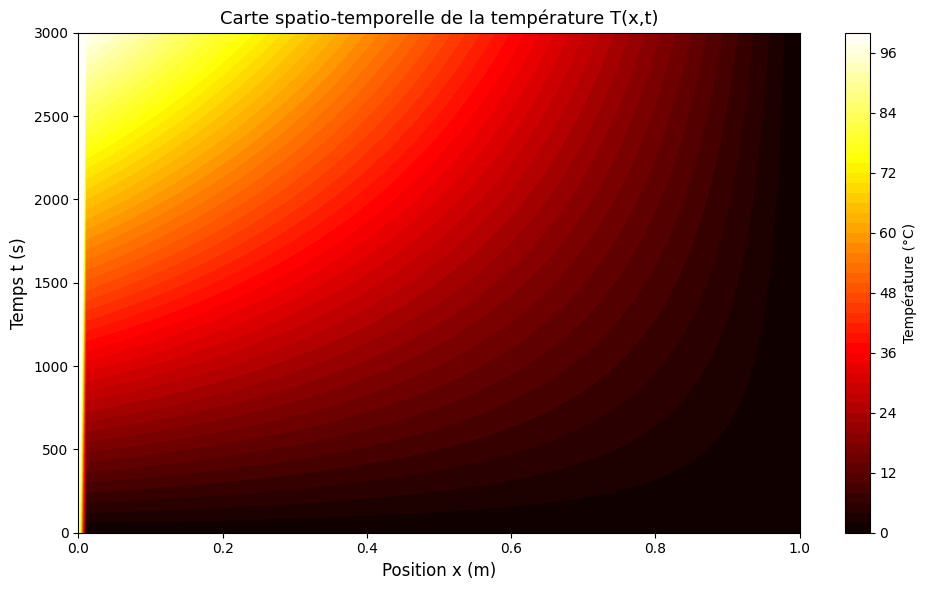

In [34]:
def f_init_zero(x):
    return np.zeros_like(x)

x, t_map, T_map = simulation_chaleur_vect_f(L, alpha, N=100, r=0.4,t_fin=3000,T_gauche=100, T_droite=0, f_init=f_init_zero,save_step_frac=1)

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(10, 6))

c = ax.contourf(x, t_map, T_map, levels=50, cmap='hot')
fig.colorbar(c, ax=ax, label='Température (°C)')

ax.set_xlabel('Position x (m)', fontsize=12)
ax.set_ylabel('Temps t (s)', fontsize=12)
ax.set_title("Carte spatio-temporelle de la température T(x,t)", fontsize=13)
plt.tight_layout()
plt.show()


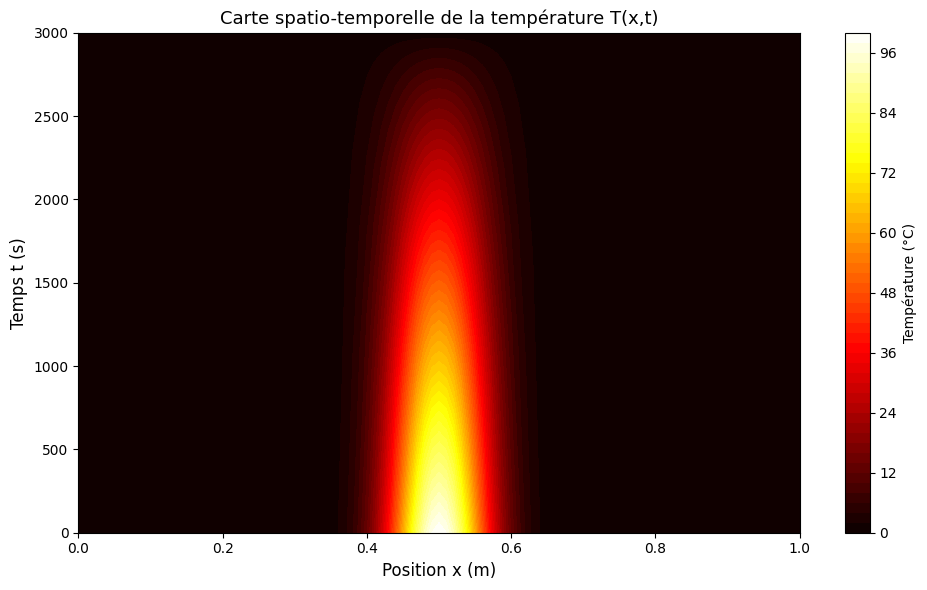

In [ ]:
def f_init_gauss(x):
    sigma= 0.05
    T_max= 100
    L = x[-1]
    return T_max* np.exp(-((x - L/2)**2)/(2*sigma**2))

x, t_map, T_map = simulation_chaleur_vect_f(L, alpha, N=100, r=0.4,t_fin=3000,T_gauche=0, T_droite=0, f_init=f_init_gauss,save_step_frac=1)

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(10, 6))

c = ax.contourf(x, t_map, T_map, levels=50, cmap='hot')
fig.colorbar(c, ax=ax, label='Température (°C)')

ax.set_xlabel('Position x (m)', fontsize=12)
ax.set_ylabel('Temps t (s)', fontsize=12)
ax.set_title("Carte spatio-temporelle de la température T(x,t)", fontsize=13)
plt.tight_layout()
plt.show()